# Precautionary Analysis Plotting
Loading and visualizing the results from the latest Bayesian optimization runs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import OptimizeResult
from skopt.plots import plot_convergence

# Load the CSV files
df_vax_all = pd.read_csv('precautionary_vax_all_iterations_20260303-132721.csv')
df_vax_vuln = pd.read_csv('precautionary_vax_vuln_iterations_20260303-132721.csv')

# Reconstruct OptimizeResult objects for skopt compatibility
res_vax_all = OptimizeResult()
res_vax_all.x_iters = df_vax_all[['death_prob', 'vax_effect', 'viral_age_effect']].values.tolist()
# The original notebook minimized negative deaths, so f_val in CSV is -func_vals
# We invert to give skopt the exact function values the optimizer tracked
res_vax_all.func_vals = -df_vax_all['f_val'].values
best_idx_all = np.argmin(res_vax_all.func_vals)
res_vax_all.x = res_vax_all.x_iters[best_idx_all]
res_vax_all.fun = res_vax_all.func_vals[best_idx_all]

res_vax_vuln = OptimizeResult()
res_vax_vuln.x_iters = df_vax_vuln[['death_prob', 'vax_effect', 'viral_age_effect']].values.tolist()
res_vax_vuln.func_vals = -df_vax_vuln['f_val'].values
best_idx_vuln = np.argmin(res_vax_vuln.func_vals)
res_vax_vuln.x = res_vax_vuln.x_iters[best_idx_vuln]
res_vax_vuln.fun = res_vax_vuln.func_vals[best_idx_vuln]

display(df_vax_all.head())
display(df_vax_vuln.head())

,death_prob,vax_effect,viral_age_effect,f_val
0,0.418411,0.283291,0.825360,0.12234
1,0.620153,0.554172,0.267951,0.12527
2,0.630701,0.387254,0.895012,0.11131
3,0.400580,0.336596,0.507050,0.13012
4,0.340391,0.533417,0.556841,0.09779


,death_prob,vax_effect,viral_age_effect,f_val
0,0.157451,0.863272,0.791406,0.12323
1,0.898041,0.631343,0.868392,0.11091
2,0.714971,0.344713,0.198025,0.12819
3,0.605920,0.777946,0.664977,0.12065
4,0.236144,0.404911,0.472936,0.16462


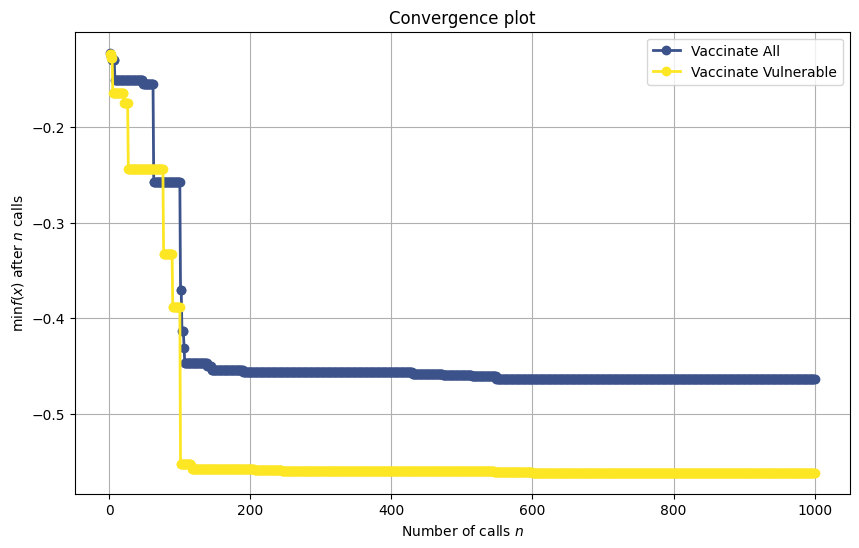

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_convergence(res_vax_all, res_vax_vuln, ax=ax)
ax.legend(['Vaccinate All', 'Vaccinate Vulnerable'])
plt.show()

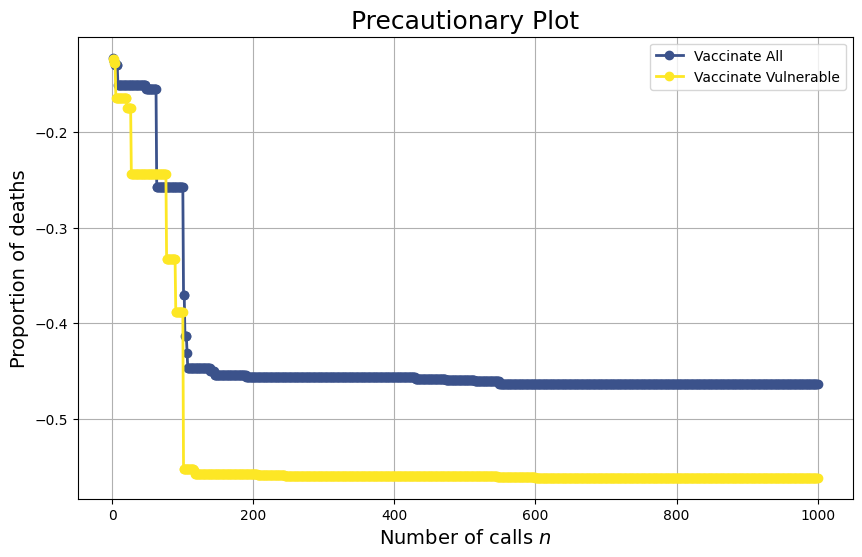

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_convergence(res_vax_all, res_vax_vuln, ax=ax)
ax.legend(['Vaccinate All', 'Vaccinate Vulnerable'])
# Update title and labels with larger fonts
ax.set_title('Precautionary Plot', fontsize=18)
ax.set_ylabel('Proportion of deaths', fontsize=14)
ax.set_xlabel('Number of calls $n$', fontsize=14)
plt.show()